In [1]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
import random

In [4]:
class AgentState(TypedDict):
    name: str
    number: int
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound:int

In [21]:
def setup_node(state: AgentState) -> AgentState:
    """Setup the player's information"""

    state["name"] = f"Hi {state["name"]}"
    state["number"] = random.randint(1, 20)
    state["attempts"] = 0
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    state["guesses"] = []

    return state

def guess_node(state: AgentState) -> AgentState:
    """This node is to judge if the gucess is correct"""

    state["guesses"].append(random.randint(state["lower_bound"], state["upper_bound"]))

    if state["guesses"][-1] > state["number"]:
        state["upper_bound"] = state["guesses"][-1]
        print("loop", state)
    elif state["guesses"][-1] < state["number"]:
        state["lower_bound"] = state["guesses"][-1]
        print("loop", state)

    state["attempts"] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["attempts"] >= 7 or state["guesses"][-1] == state["number"]:
        return "exit"
    else:
        return "continue"

In [22]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")

graph.add_conditional_edges(
    "guess",
    should_continue,
    {
        "continue": "guess",
        "exit": END
    }
)

app = graph.compile()

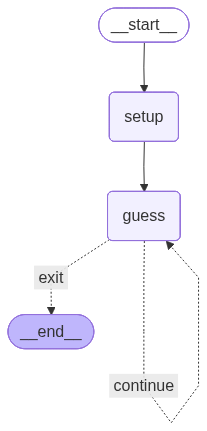

In [23]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
app.invoke({"name": "Student"})

loop {'name': 'Hi Student', 'number': 12, 'guesses': [4], 'attempts': 0, 'lower_bound': 4, 'upper_bound': 20}
loop {'name': 'Hi Student', 'number': 12, 'guesses': [4, 7], 'attempts': 1, 'lower_bound': 7, 'upper_bound': 20}


{'name': 'Hi Student',
 'number': 12,
 'guesses': [4, 7, 12],
 'attempts': 3,
 'lower_bound': 7,
 'upper_bound': 20}